# Analisi repository di git con più stelle
Analisi delle repository più famose di git
Dipendenze:
- Matplotlib
- Pandas
- numpy

Utilizzare un venv

In [28]:
import pandas
import os

datasets = []

for domain in os.listdir("../data/domains"):
    datasets.append((domain.split(".")[0], pandas.read_csv(os.path.join("../data/domains", domain))))

print("Lista di dataset: " + str([x[0] for x in datasets]))

Lista di dataset: ['Machine Learning', 'Deep Learning', 'Python', 'JavaScript', 'Java', 'C++', 'Go', 'Rust', 'Data Science', 'Web Development', 'Android', 'iOS', 'Blockchain', 'Cybersecurity', 'DevOps']


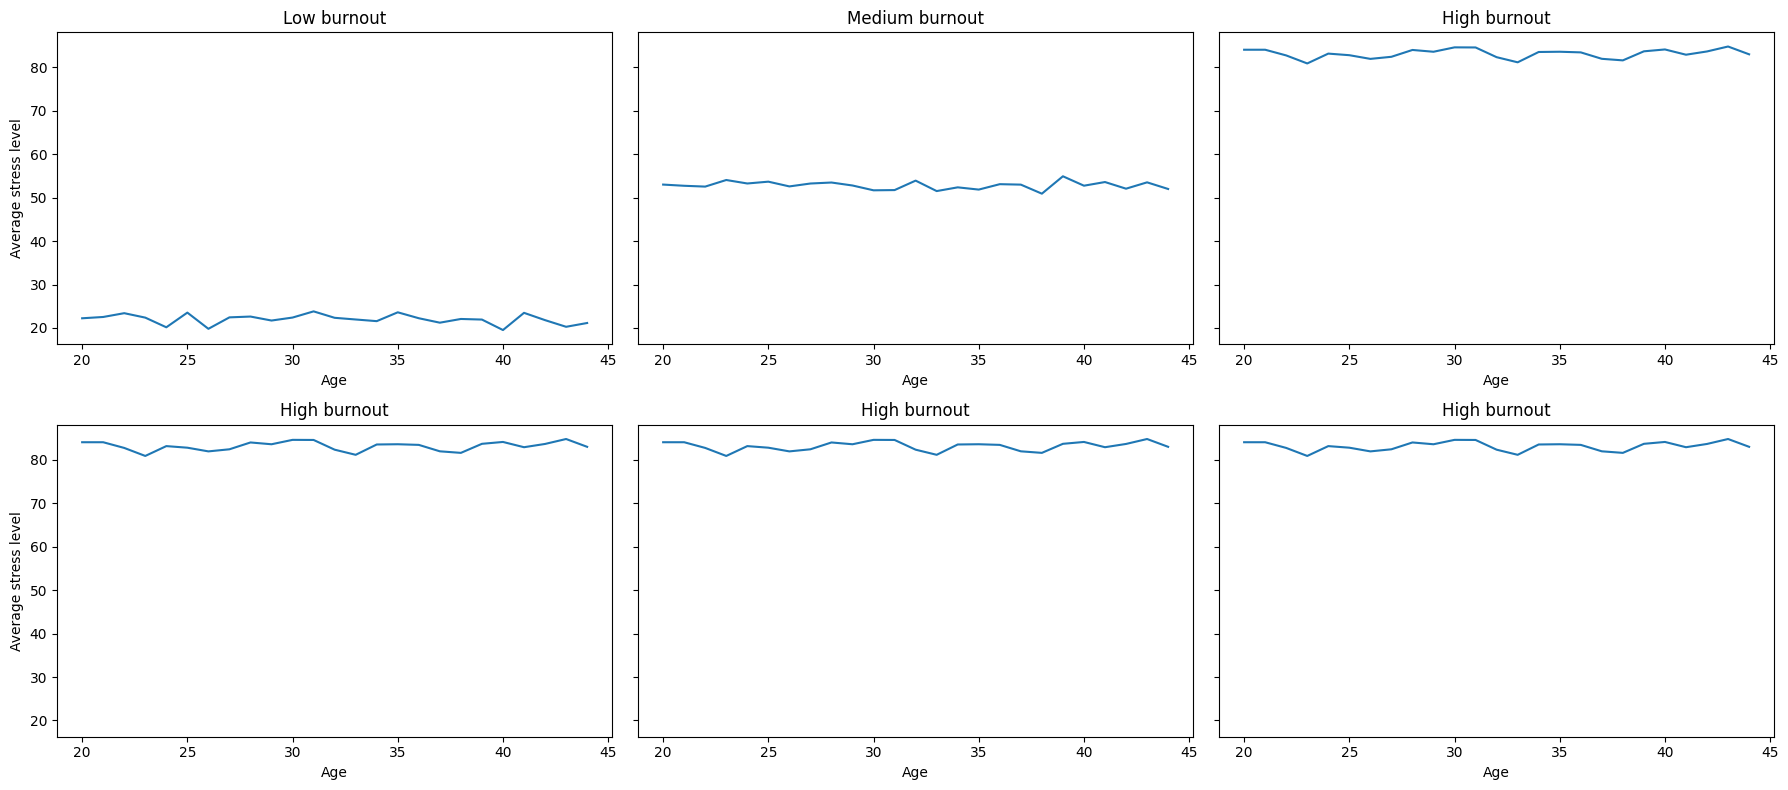

In [14]:
import matplotlib.pyplot as plt
import numpy as np

datasets = [low_burnout, medium_burnout, high_burnout, high_burnout, high_burnout , high_burnout]
titles = ["Low burnout", "Medium burnout", "High burnout",
          "High burnout", "High burnout", "High burnout"]

fig, ax = plt.subplots(2, 3, figsize=(18, 8), sharey=True)

for i, (df, title) in enumerate(zip(datasets, titles)):
    row = i // 3
    col = i % 3

    summary = df.groupby("age")["stress_level"].mean()

    ax[row, col].plot(summary.index, summary.values)
    ax[row, col].set_title(title)
    ax[row, col].set_xlabel("Age")

ax[0, 0].set_ylabel("Average stress level")
ax[1, 0].set_ylabel("Average stress level")

plt.tight_layout()
plt.show()

<Axes: xlabel='experience_years'>

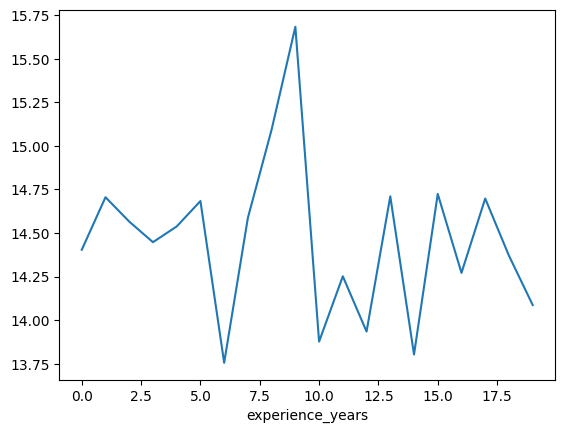

In [36]:
commits = dataset.groupby("experience_years")["commits_per_day"].mean()
commits.plot()

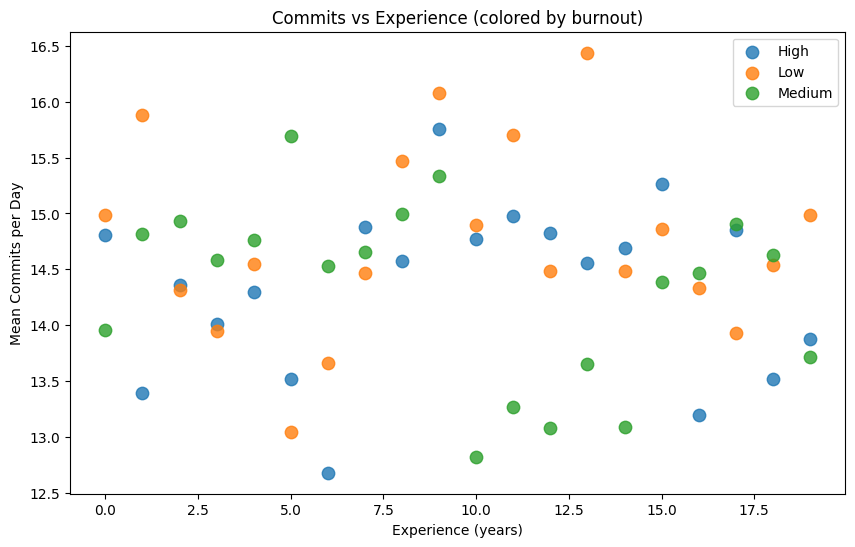

In [38]:
grouped = dataset.groupby(["experience_years", "burnout_level"])["commits_per_day"].mean().reset_index()
burnout_colors = {
    "Low": "green",
    "Medium": "orange",
    "High": "red"
}
grouped["color"] = grouped["burnout_level"].map(burnout_colors)
plt.figure(figsize=(10, 6))

for burnout_level in grouped["burnout_level"].unique():
    subset = grouped[grouped["burnout_level"] == burnout_level]
    
    plt.scatter(
        subset["experience_years"],
        subset["commits_per_day"],
        label=burnout_level,
        alpha=0.8,
        s=80
    )

plt.xlabel("Experience (years)")
plt.ylabel("Mean Commits per Day")
plt.title("Commits vs Experience (colored by burnout)")
plt.legend()
plt.show()